# Customer Spending Prediction using Multiple Linear Regression

Predicts **Yearly Amount Spent** by e-commerce customers from four features: Avg. Session Length, Time on App, Time on Website, and Length of Membership.

**Steps:** exploratory data analysis (Seaborn) → train/test split → Linear Regression (Scikit-learn) → evaluation (MAE, MSE, RMSE) → residual analysis.

**Dataset:** Ecommerce Customers (`Ecommerce Customers.csv`, keep it in the same folder/session as this notebook).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('Ecommerce Customers.csv')
data.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


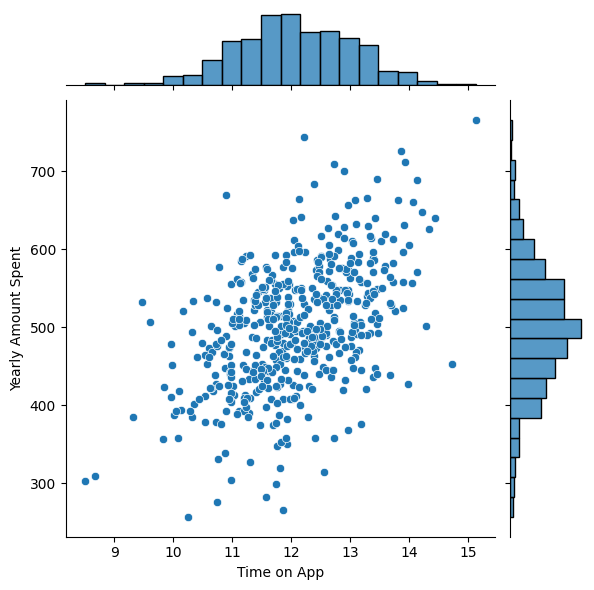

In [5]:
#EDA
sns.jointplot(x='Time on App',y='Yearly Amount Spent',data=data)

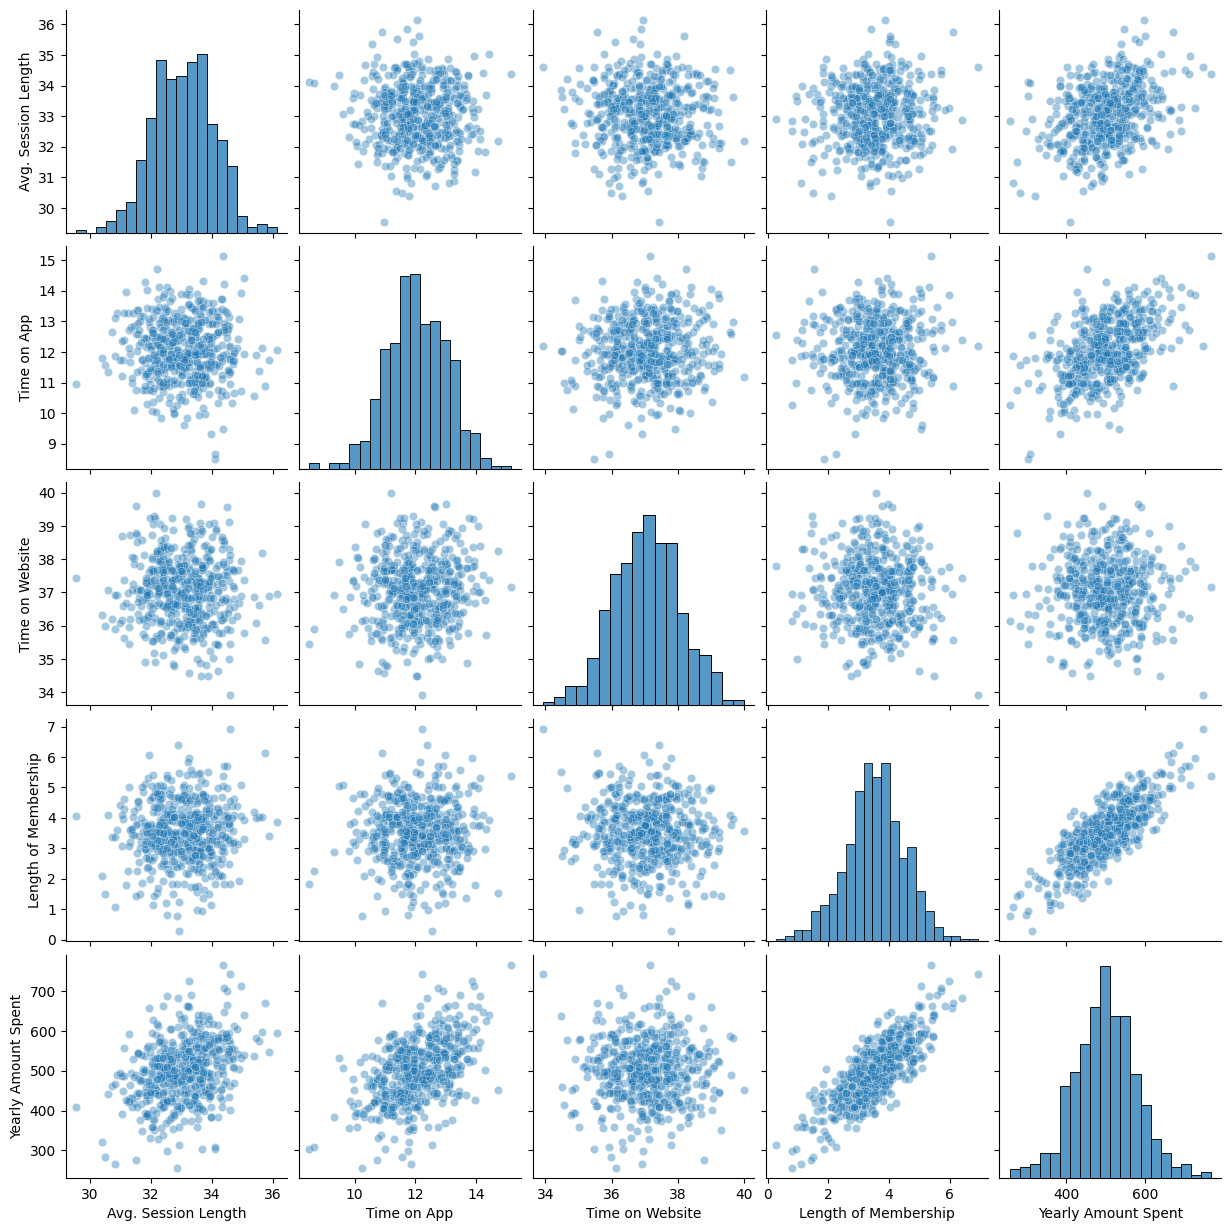

In [6]:
sns.pairplot(data,kind="scatter", plot_kws={"alpha":0.4},)

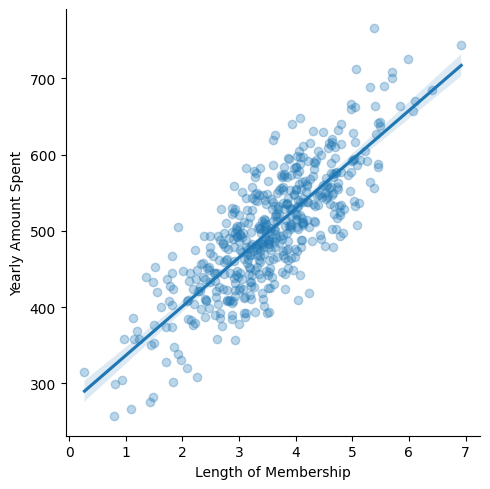

In [7]:
sns.lmplot(data = data, x='Length of Membership', y ='Yearly Amount Spent',scatter_kws={'alpha':0.3},)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x = data[['Time on App', 'Avg. Session Length', 'Time on Website','Length of Membership',]]
y = data['Yearly Amount Spent']

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [11]:
x_train

,Time on App,Avg. Session Length,Time on Website,Length of Membership
5,12.026925,33.871038,34.476878,5.493507
116,12.011022,33.925795,36.701052,2.753424
45,12.170525,34.555768,39.131097,3.663105
16,11.733862,32.125387,34.894093,3.136133
462,11.233415,33.503810,37.211153,2.320550
...,...,...,...,...
106,12.190474,32.291756,36.152462,3.781823
270,12.956277,34.006489,38.655095,3.275734
348,10.886921,31.812483,34.897828,3.128639
435,14.132893,32.259973,37.023479,3.762070


In [12]:
x_test

,Time on App,Avg. Session Length,Time on Website,Length of Membership
361,10.347877,32.077590,39.045156,3.434560
73,12.817113,32.808698,37.031539,3.851579
374,10.101632,31.447446,38.043453,4.238296
155,13.457725,32.449522,37.238806,2.941411
104,10.994224,31.389585,38.074452,3.428860
...,...,...,...,...
266,11.777772,34.555283,37.979827,3.784273
23,11.657576,32.903251,36.772604,3.919302
222,11.109456,34.334865,38.585855,3.892891
261,13.041245,32.550527,36.655208,3.456234


In [13]:
y_test

,Yearly Amount Spent
361,401.033135
73,534.777188
374,418.602742
155,503.978379
104,410.069611
...,...
266,554.003093
23,519.340989
222,502.409785
261,514.009818


In [14]:
y_train

,Yearly Amount Spent
5,637.102448
116,479.231093
45,549.860590
16,457.847696
462,397.420584
...,...
106,494.551861
270,540.995739
348,392.810345
435,571.216005


In [15]:
#training the model
from sklearn.linear_model import LinearRegression

In [16]:
lm = LinearRegression()

In [17]:
lm.fit(x_train,y_train)

LinearRegression()

In [18]:
lm.coef_

array([38.59713548, 25.72425621,  0.45914788, 61.67473243])

In [19]:
cdf = pd.DataFrame(lm.coef_,x.columns,columns=['Coeff'])
print(cdf)

                          Coeff
Time on App           38.597135
Avg. Session Length   25.724256
Time on Website        0.459148
Length of Membership  61.674732


In [20]:
#prediction


In [21]:
predictions = lm.predict(x_test)

In [22]:
predictions

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

Text(0.5, 1.0, 'Evaluation of our LM Model')

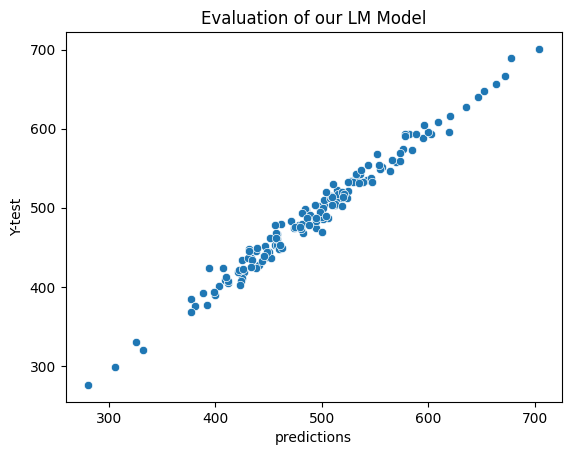

In [23]:
import matplotlib.pyplot as plt
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel('predictions')
plt.ylabel('Y-test')
plt.title('Evaluation of our LM Model')

In [24]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import math

In [25]:
print("Mean Absolute Error:" ,mean_absolute_error(y_test,predictions))
print("Mean Squared Error:" ,mean_squared_error(y_test,predictions))
print("Root Mean Squared Error:" ,math.sqrt(mean_squared_error(y_test,predictions)))


Mean Absolute Error: 8.426091641432114
Mean Squared Error: 103.91554136503329
Root Mean Squared Error: 10.193897260863153


In [26]:
residuals = y_test - predictions

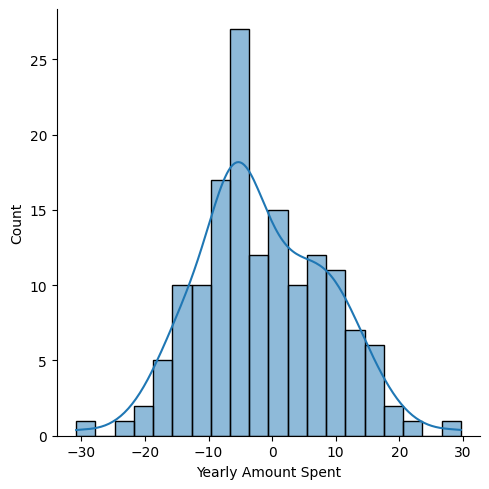

In [27]:
sns.displot(residuals, bins = 20,kde = True)

In [28]:
import pylab

In [29]:
import scipy.stats as stats

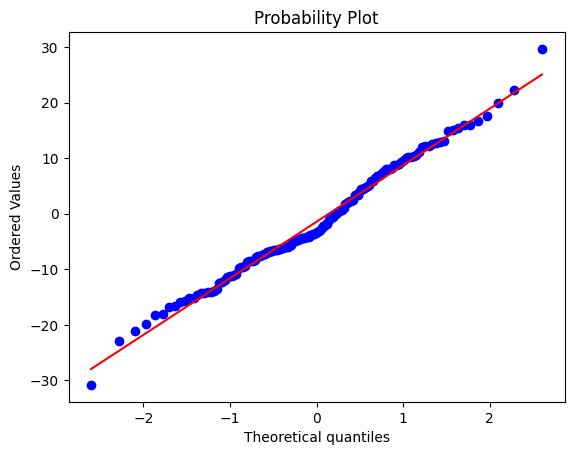

In [30]:
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()